In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import matplotlib.dates as mdates


plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 150,
})

# 1. Load Data

In [36]:
df = pd.read_csv('../../output/04_Regression_handled.csv')

print('Shape    :', df.shape)
print('Day range:', df['day'].min(), 'to', df['day'].max())
print('\nSector names in data:')
print(df['sector'].value_counts().to_string())

Shape    : (70413, 19)
Day range: -298 to 91

Sector names in data:
sector
Food & Beverage               11200
Diversified Financials        10112
Consumer Services              8293
Capital Goods                  7558
Materials                      5753
Banks                          4348
Real Estate                    4032
Retailing                      3443
Insurance                      3283
Utilities                      2297
Healthcare Equipment           2270
Consumer Durables              2045
Commercial Services            1603
Food Retailing                 1010
Energy                          767
Transportation                  727
Telecommunication Services      514
Others                          327
Household Products              317
Software & Services             257
Automobiles                     257


## 2. Filters

**Filter 1 — Thin trading:**  Remove stocks with trading days < 60 in estimate window

**Filter 2 — Extreme beta:**  Removed stocks with extreme beta values (outliers)

**Filter 3 — Micro-sectors:**  Removed sectors with stocks < 5

In [37]:
# ── Filter 1: Thin trading ────────────────────────────────────────────────────
est_window = df[(df['day'] >= -120) & (df['day'] <= -6)]

trading_days = (
    est_window.groupby('symbol')['day']
    .count()
    .reset_index()
    .rename(columns={'day': 'trading_days'})
)

sufficient = trading_days[trading_days['trading_days'] >= 60]['symbol']
dropped_thin = len(trading_days) - len(sufficient)
df = df[df['symbol'].isin(sufficient)].copy()
print(f'Filter 1 — thin trading  : dropped {dropped_thin} stocks, kept {len(sufficient)}')

# ── Filter 2: Extreme beta ────────────────────────────────────────────────────
beta_per_stock = (
    df[(df['day'] >= -120) & (df['day'] <= -6)]
    .groupby('symbol')['beta']
    .first()
    .reset_index()
)

valid_beta = beta_per_stock[
    (beta_per_stock['beta'] >= -3) &
    (beta_per_stock['beta'] <=  5)
]['symbol']

dropped_beta = len(beta_per_stock) - len(valid_beta)
df = df[df['symbol'].isin(valid_beta)].copy()
print(f'Filter 2 — extreme beta  : dropped {dropped_beta} stocks, kept {len(valid_beta)}')


Filter 1 — thin trading  : dropped 6 stocks, kept 258
Filter 2 — extreme beta  : dropped 20 stocks, kept 238


## 3. Compute Abnormal Return (AR)
`AR = R_i − (alpha + beta × R_m)`

In [38]:
df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])

# Sanity check — mean AR in estimation window should be ≈ 0
mean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()
print(f'Mean AR in estimation window: {mean_ar:.6f}')

est_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()
event_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()

Mean AR in estimation window: 0.000000


## 4. Compute CAR per Stock over the Event Window

In [39]:
event_df = event_df.sort_values(['symbol', 'day'])
event_df['CAR']     = event_df.groupby('symbol')['AR'].cumsum()
event_df['CAR_pct'] = event_df['CAR'] * 100

## 5. Aggregate Mean CAR by Sector and Day

In [40]:
sector_car = (
    event_df
    .groupby(['sector', 'day'])['CAR_pct']
    .mean()
    .reset_index()
    .rename(columns={'CAR_pct': 'mean_CAR_pct'})
)

print('Mean CAR on Day 0 by sector (cleaned):')
print(
    sector_car[sector_car['day'] == 0]
    .sort_values('mean_CAR_pct')
    .to_string(index=False)
)

Mean CAR on Day 0 by sector (cleaned):
                    sector  day  mean_CAR_pct
            Transportation    0     -5.740862
               Real Estate    0     -3.450824
Telecommunication Services    0     -3.169645
                 Materials    0     -1.840189
                     Banks    0     -1.820985
                 Insurance    0     -1.670399
             Capital Goods    0     -1.579852
    Diversified Financials    0     -1.406438
       Software & Services    0     -1.203490
        Household Products    0     -0.870133
           Food & Beverage    0     -0.681509
                    Energy    0     -0.650505
            Food Retailing    0     -0.359182
      Healthcare Equipment    0     -0.312457
                 Utilities    0     -0.087538
         Consumer Durables    0     -0.008622
         Consumer Services    0      0.572159
                    Others    0      0.623473
                 Retailing    0      1.325078
               Automobiles    0      1.57

In [41]:
market_car = {}

windows = {
    'CAR(-5,-1)' : (-5, -1),
    'CAR(0,0)'   : ( 0,  0),
    'CAR(0,+5)'  : ( 0,  5),
    'CAR(-5,+30)': (-5, 30),
}


for label, (t1, t2) in windows.items():
    window_data = event_df[(event_df['day'] >= t1) & (event_df['day'] <= t2)]
    stock_car = window_data.groupby('symbol')['AR'].sum() * 100
    market_car[label] = {
        'mean'   : round(stock_car.mean(), 3),
        'std'    : round(stock_car.std(), 3),
        'n'      : len(stock_car)
    }

market_df = pd.DataFrame(market_car).T
print('Market-level CAR summary:')
print(market_df.to_string())

Market-level CAR summary:
              mean     std      n
CAR(-5,-1)  -0.767   4.554  238.0
CAR(0,0)    -0.044   2.646  234.0
CAR(0,+5)   -1.729   5.943  238.0
CAR(-5,+30) -4.386  11.375  238.0


## Figure 0 — ASPI Index Trajectory
Daily ASPI close from Feb 2025 to Feb 2026 with landfall marker at Day 0.

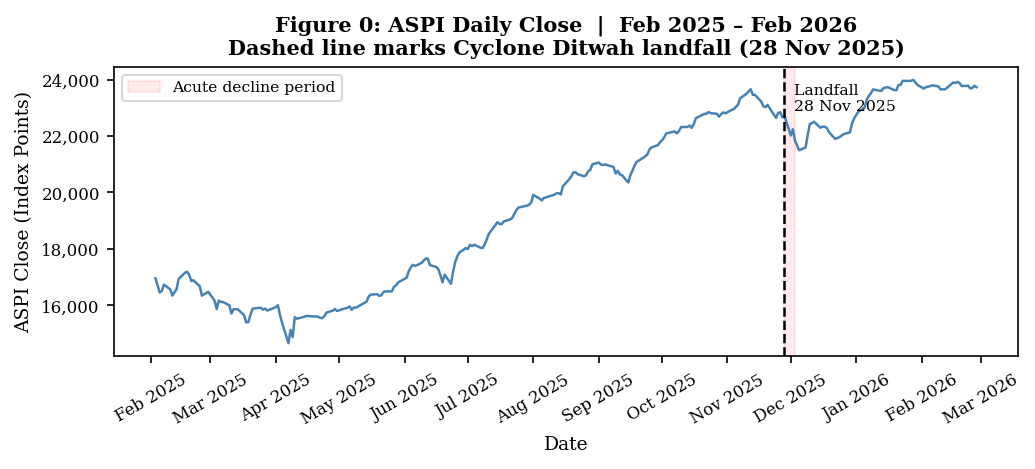

In [42]:
# ── ASPI trajectory: one row per trading date ────────────────────────────────
aspi_daily = (
    df[['date', 'day', 'aspi_close']]
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

# Identify Day 0 date (landfall)
landfall_date = aspi_daily.loc[aspi_daily['day'] == 0, 'date'].values
if len(landfall_date) == 0:
    landfall_date = aspi_daily.loc[(aspi_daily['day'] - 0).abs().idxmin(), 'date']
else:
    landfall_date = landfall_date[0]

aspi_daily['date_dt'] = pd.to_datetime(aspi_daily['date'])
landfall_dt = pd.to_datetime(landfall_date)

fig0, ax0 = plt.subplots(figsize=(7, 3.2))

ax0.plot(
    aspi_daily['date_dt'],
    aspi_daily['aspi_close'],
    color='steelblue',
    linewidth=1.2,
    zorder=2
)

ax0.axvline(
    x=landfall_dt,
    color='black',
    linewidth=1.2,
    linestyle='--',
    zorder=3
)
ax0.text(
    landfall_dt,
    aspi_daily['aspi_close'].max() * 0.995,
    '  Landfall\n  28 Nov 2025',
    fontsize=7.5,
    va='top',
    color='black'
)

trough_date = aspi_daily.loc[(aspi_daily['day'] - 5).abs().idxmin(), 'date_dt']
ax0.axvspan(
    landfall_dt, trough_date,
    alpha=0.08, color='red', zorder=1,
    label='Acute decline period'
)

ax0.set_xlabel('Date')
ax0.set_ylabel('ASPI Close (Index Points)')
ax0.set_title(
    'Figure 0: ASPI Daily Close  |  Feb 2025 – Feb 2026\n'
    'Dashed line marks Cyclone Ditwah landfall (28 Nov 2025)',
    pad=6
)

ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax0.tick_params(axis='x', rotation=30)

ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax0.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
fig0.savefig('../../figures/figure_aspi.pdf', bbox_inches='tight')
plt.show()


## Figure 1 — Sector CAR over the Event Window

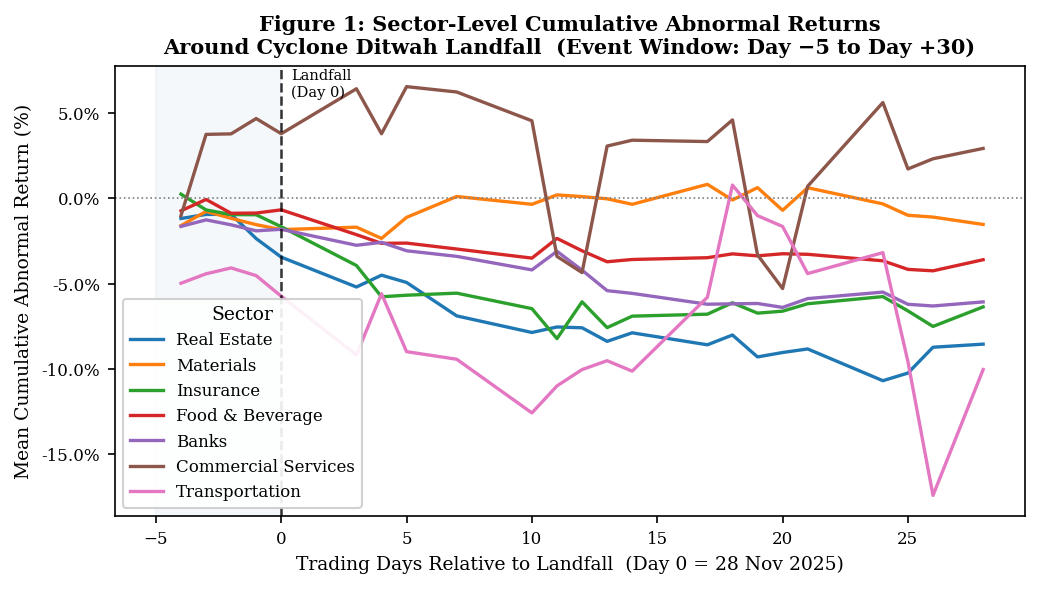

In [43]:
sectors = [
    'Real Estate',
    'Materials',
    'Insurance',
    'Food & Beverage',
    'Banks',
    'Commercial Services',
    'Transportation'
]

sector_car_plot = sector_car[sector_car['sector'].isin(sectors)].copy()
palette = sns.color_palette('tab10', n_colors=len(sectors))
col_map = dict(zip(sectors, palette))

fig1, ax1 = plt.subplots(figsize=(7, 4))

for sector in sectors:
    data = sector_car_plot[sector_car_plot['sector'] == sector].sort_values('day')
    ax1.plot(
        data['day'],
        data['mean_CAR_pct'],
        label=sector,
        color=col_map[sector],
        linewidth=1.6
    )

# Landfall marker
ax1.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.8)
ax1.text(0.4, ax1.get_ylim()[1] * 0.98,
         'Landfall\n(Day 0)', fontsize=7, color='black', va='top')

# Zero baseline
ax1.axhline(y=0, color='grey', linewidth=0.8, linestyle=':')

# Shade anticipation period
ax1.axvspan(-5, 0, alpha=0.05, color='steelblue')

ax1.set_xlabel('Trading Days Relative to Landfall  (Day 0 = 28 Nov 2025)')
ax1.set_ylabel('Mean Cumulative Abnormal Return (%)')
ax1.set_title(
    'Figure 1: Sector-Level Cumulative Abnormal Returns\n'
    'Around Cyclone Ditwah Landfall  (Event Window: Day −5 to Day +30)'
)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.legend(title='Sector', loc='lower left', framealpha=0.9)

plt.tight_layout()
fig1.savefig('../../figures/figure1_sector_CAR.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — Pre-Event Beta Distribution by Sector
Outliers beyond β ∈ [−3, 5] removed (thin-trading artefacts).

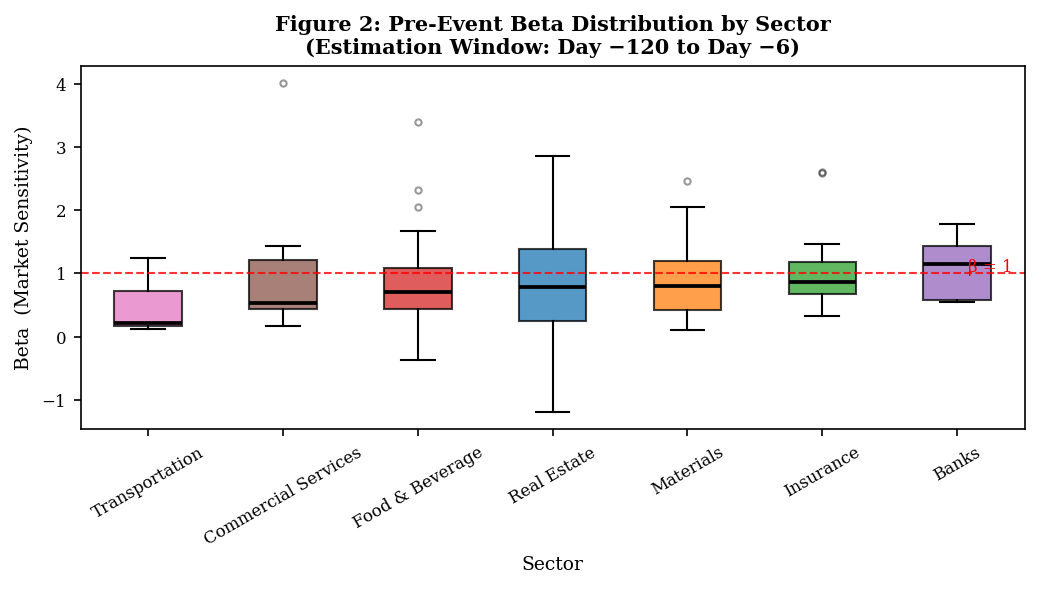

In [44]:
beta_per_stock = (
    est_df
    .groupby(['symbol', 'sector'])['beta']
    .first()
    .reset_index()
)

df_plot = beta_per_stock[beta_per_stock['sector'].isin(sectors)].copy()

# Sort by median beta low → high
sector_order = (
    df_plot.groupby('sector')['beta']
    .median()
    .sort_values()
    .index.tolist()
)

palette2 = [col_map[s] for s in sector_order]

fig2, ax2 = plt.subplots(figsize=(7, 4))

bp = ax2.boxplot(
    [df_plot[df_plot['sector'] == s]['beta'].values for s in sector_order],
    tick_labels=sector_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

for patch, colour in zip(bp['boxes'], palette2):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax2.axhline(y=1, color='red', linewidth=1, linestyle='--', alpha=0.8)
ax2.text(len(sector_order) + 0.08, 1.03, 'β = 1', fontsize=8, color='red')

ax2.set_xlabel('Sector')
ax2.set_ylabel('Beta  (Market Sensitivity)')
ax2.set_title(
    'Figure 2: Pre-Event Beta Distribution by Sector\n'
    '(Estimation Window: Day −120 to Day −6)'
)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
fig2.savefig('../../figures/figure2_beta_by_sector.pdf', bbox_inches='tight')
plt.show()

In [45]:
rows = []
for sector in sorted(event_df['sector'].unique()):
    sec_df = event_df[event_df['sector'] == sector]
    row = {'Sector': sector}
    for label, (t1, t2) in windows.items():
        window_data = sec_df[
            (sec_df['day'] >= t1) &
            (sec_df['day'] <= t2)
        ]
        stock_car = window_data.groupby('symbol')['AR'].sum() * 100
        row[label] = round(stock_car.mean(), 2)
    rows.append(row)

car_table = pd.DataFrame(rows).set_index('Sector')

print('CAR Summary Table (mean % per sector):')
print(car_table.to_string())

car_table.to_csv('../../output/car_summary_table.csv')

CAR Summary Table (mean % per sector):
                            CAR(-5,-1)  CAR(0,0)  CAR(0,+5)  CAR(-5,+30)
Sector                                                                  
Automobiles                       1.42      0.16      -0.66         2.43
Banks                            -1.91      0.09      -1.17        -6.07
Capital Goods                    -1.70      0.12      -0.22        -2.97
Commercial Services               4.66     -0.73       1.87         0.27
Consumer Durables                 0.24     -0.25       0.65        -2.28
Consumer Services                 0.90     -0.33      -3.83        -3.97
Diversified Financials           -0.96     -0.34      -2.44        -6.69
Energy                           -0.70      0.05      -0.69        -2.09
Food & Beverage                  -0.87      0.19      -1.76        -4.18
Food Retailing                   -0.02     -0.34       1.54        -0.04
Healthcare Equipment             -0.89      0.58       1.89        -0.66
Household Pr